# Hospital Readmission Fairness Audit
## Notebook 02 - Baseline Models, Explainability & Fairness Metrics

This notebook covers **Section 3 (baseline models + explainability)** and **Section 4 (fairness metrics on the baseline)**.

> **How to run this notebook**
>
> Open it in **Google Colab** (or a local Jupyter install with internet access) and run the cells top to bottom (`Runtime -> Run all`).
> The first code cell installs the extra packages; the next cell downloads the dataset automatically from the UCI ML Repository.
> Run **Notebook 01 first** — it saves `diabetic_clean.csv`, which notebooks 02 and 03 reuse. (02 and 03 will rebuild it automatically if it is missing.)

## Section 3 - Baseline Models & Explainability

We train two models with deliberately different transparency profiles:
- **Logistic Regression** - a *whitebox* model, interpretable by design.
- **Random Forest** - a *blackbox* model, needing post-hoc explanation (SHAP).

Both use `class_weight='balanced'` because only ~17% of patients are readmitted; without it the models would simply predict "not readmitted" for almost everyone and the false-negative analysis would be meaningless.

In [13]:
!pip -q install ucimlrepo fairlearn shap


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\yolo swaggins\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned data from Notebook 01; rebuild it if it is missing.
try:
    df = pd.read_csv('diabetic_clean.csv')
except FileNotFoundError:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=296)
    df = pd.concat([ds.data.features, ds.data.targets], axis=1).replace('?', np.nan)
    df = df[df['readmitted'] != '>30'].copy()
    df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

print('Data loaded:', df.shape)

Data loaded: (66221, 49)


### 3.1 Preprocessing
We drop the few `Unknown/Invalid` gender rows and the ~2% of rows with missing race (so the per-race fairness analysis is clean), build a 3-bin `age_group` for readable fairness tables, select a focused feature set, fill missing values, and one-hot encode the categoricals. We deliberately keep `payer_code` in the feature set - part of the audit is to see whether the model leans on this racial proxy.

In [15]:
df = df[df['gender'] != 'Unknown/Invalid'].copy()
df = df.dropna(subset=['race']).reset_index(drop=True)

def age_bin(a):
    young = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)']
    mid = ['[60-70)', '[70-80)']
    return 'Under 60' if a in young else ('60-80' if a in mid else '80+')

df['age_group'] = df['age'].apply(age_bin)

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
cat_cols = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
            'admission_source_id', 'payer_code', 'max_glu_serum', 'A1Cresult',
            'metformin', 'insulin', 'change', 'diabetesMed']

X_df = df[num_cols + cat_cols].copy()
X_df[num_cols] = X_df[num_cols].fillna(X_df[num_cols].median())
for col in cat_cols:
    X_df[col] = X_df[col].fillna('None').astype(str)

X = pd.get_dummies(X_df, columns=cat_cols)
y = df['readmit_30'].values
print('Feature matrix after one-hot encoding:', X.shape)

Feature matrix after one-hot encoding: (64485, 113)


In [16]:
from sklearn.model_selection import train_test_split

# Stratify the split by race so every group keeps its proportions in train and test.
idx = np.arange(len(df))
Xtr, Xte, ytr, yte, itr, ite = train_test_split(
    X, y, idx, test_size=0.25, random_state=42, stratify=df['race'])

# Sensitive attributes aligned to the TEST set, for the fairness analysis.
sens = df.iloc[ite][['race', 'gender', 'age_group']].reset_index(drop=True)
print('Train:', Xtr.shape, '  Test:', Xte.shape)

Train: (48363, 113)   Test: (16122, 113)


### 3.2 Train the models and report overall performance

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
logreg.fit(Xtr_s, ytr)

rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
print('Both models trained.')

Both models trained.


In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score

lr_pred = logreg.predict(Xte_s)
lr_prob = logreg.predict_proba(Xte_s)[:, 1]
rf_pred = rf.predict(Xte)
rf_prob = rf.predict_proba(Xte)[:, 1]

for name, pred, prob in [('Logistic Regression', lr_pred, lr_prob),
                         ('Random Forest', rf_pred, rf_prob)]:
    print('%-22s accuracy=%.3f  AUC=%.3f' % (
        name, accuracy_score(yte, pred), roc_auc_score(yte, prob)))

Logistic Regression    accuracy=0.704  AUC=0.720
Random Forest          accuracy=0.722  AUC=0.723


### 3.2 Per-group performance
`MetricFrame` from Fairlearn breaks a metric down by group. This is the first signal of where a model fails specific groups - a strong overall AUC can still hide a much weaker false-negative rate for one race.

In [19]:
from fairlearn.metrics import (MetricFrame, false_negative_rate,
                               false_positive_rate, selection_rate)
from sklearn.metrics import accuracy_score

metrics = {'accuracy': accuracy_score, 'selection_rate': selection_rate,
           'FNR': false_negative_rate, 'FPR': false_positive_rate}

for sf in ['race', 'gender', 'age_group']:
    mf = MetricFrame(metrics=metrics, y_true=yte, y_pred=rf_pred,
                     sensitive_features=sens[sf])
    print('=== Random Forest performance by', sf, '===')
    print(mf.by_group.round(3))
    print()

=== Random Forest performance by race ===
                 accuracy  selection_rate    FNR    FPR
race                                                   
AfricanAmerican     0.741           0.277  0.450  0.217
Asian               0.842           0.183  0.421  0.109
Caucasian           0.713           0.308  0.441  0.253
Hispanic            0.774           0.203  0.569  0.158
Other               0.777           0.208  0.548  0.161

=== Random Forest performance by gender ===
        accuracy  selection_rate    FNR    FPR
gender                                        
Female     0.711           0.317  0.422  0.258
Male       0.734           0.273  0.477  0.223

=== Random Forest performance by age_group ===
           accuracy  selection_rate    FNR    FPR
age_group                                        
60-80         0.697           0.323  0.447  0.270
80+           0.640           0.387  0.433  0.343
Under 60      0.806           0.208  0.456  0.146



### 3.3 Explainability - whitebox vs blackbox

**Logistic Regression is a whitebox model.** It is interpretable *by design*: each feature has exactly one signed coefficient, and the sign and size tell you directly how that feature pushes the prediction. No extra method is needed - we just read the coefficients.

**Random Forest is a blackbox model.** Its prediction is a vote over hundreds of trees; there is no single coefficient to read. To explain it we need a *post-hoc* method - here **SHAP**, which attributes each prediction to its features in a theoretically grounded way.

A central audit question: does `payer_code` (the weak proxy flagged in Section 2) show up among the top drivers, and is `discharge_disposition_id` influential for clinically legitimate reasons rather than biased ones?

Top 10 features INCREASING 30-day readmission risk:
discharge_disposition_id_1     0.082
discharge_disposition_id_18    0.085
discharge_disposition_id_2     0.103
discharge_disposition_id_5     0.134
number_diagnoses               0.137
discharge_disposition_id_6     0.138
discharge_disposition_id_3     0.164
number_emergency               0.187
discharge_disposition_id_22    0.217
number_inpatient               0.575
dtype: float64

Top 10 features DECREASING readmission risk:
discharge_disposition_id_11   -1.333
admission_type_id_7           -0.131
discharge_disposition_id_13   -0.106
discharge_disposition_id_19   -0.098
discharge_disposition_id_17   -0.090
discharge_disposition_id_14   -0.084
admission_source_id_17        -0.075
diabetesMed_No                -0.075
admission_source_id_10        -0.073
payer_code_BC                 -0.065
dtype: float64


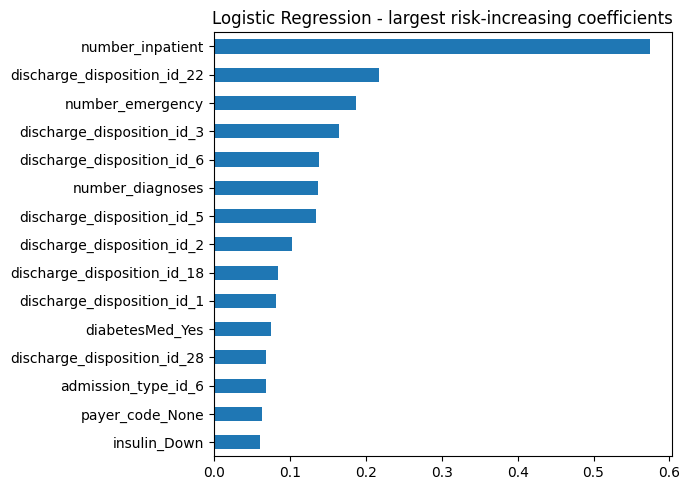

In [20]:
# Whitebox: read the Logistic Regression coefficients directly.
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print('Top 10 features INCREASING 30-day readmission risk:')
print(coef.tail(10).round(3))
print()
print('Top 10 features DECREASING readmission risk:')
print(coef.head(10).round(3))

coef.tail(15).plot(kind='barh', figsize=(7, 5),
                   title='Logistic Regression - largest risk-increasing coefficients')
plt.tight_layout()
plt.show()

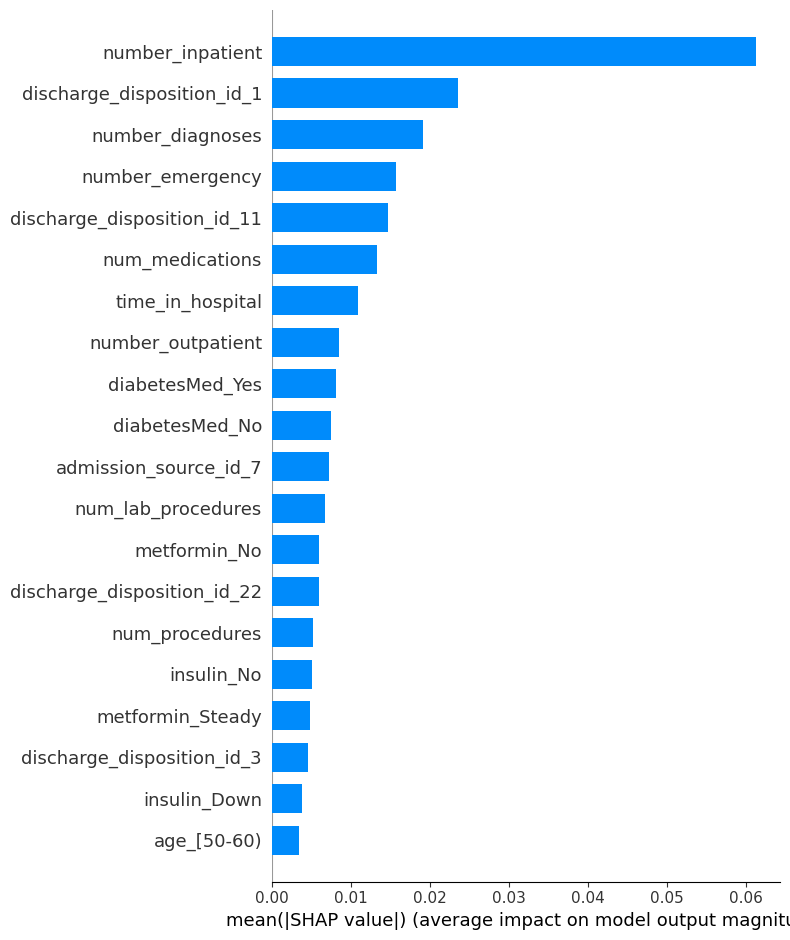

In [21]:
# Blackbox: explain the Random Forest with SHAP (sampled for speed).
import shap

sample = Xte.sample(min(500, len(Xte)), random_state=0)
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(sample)

# Different SHAP versions return the positive class differently; handle both.
if isinstance(sv, list):
    sv_pos = sv[1]
elif getattr(sv, 'ndim', 2) == 3:
    sv_pos = sv[:, :, 1]
else:
    sv_pos = sv

shap.summary_plot(sv_pos, sample, plot_type='bar', show=True)

**Comparing the two explanations.** The logistic regression coefficients and the SHAP importances should be read together: where they agree on a top feature, we can be fairly confident it is a genuine driver; where they disagree, the random forest is likely exploiting a non-linear interaction the linear model cannot see. In practice the strongest drivers here are prior-utilisation counts (`number_inpatient`, `number_emergency`) and `discharge_disposition_id`. That `discharge_disposition_id` ranks highly is mostly **clinically legitimate** - for example disposition code 11 (expired) trivially predicts no readmission - rather than evidence of bias. Reassuringly, `payer_code` does **not** surface as a top driver, which is consistent with the weak proxy association found in Section 2.

## Section 4 - Fairness Metrics on the Baseline

We compute four fairness metrics, broken down by race, gender and age group. They answer different questions and can disagree:

| Metric | What it measures | Why it matters here |
|---|---|---|
| Demographic parity | Equal positive-prediction rates across groups | Are some groups flagged high-risk at very different rates? |
| Equal opportunity (FNR) | Equal false-negative rates across groups | **Most critical** - unequal FNR means one group's sick patients are sent home more often |
| Equalized odds | Equal FPR *and* FNR simultaneously | Stronger criterion - shows whether it is achievable and at what cost |
| Calibration | Predicted probability = actual readmission rate | Does a score of 0.7 mean the same thing for every group? |

**Why FNR is the priority metric.** In Section 1 we argued that a false negative - a high-risk patient wrongly sent home - is the costliest clinical error. If one racial group has a systematically higher FNR, that group's sick patients are disproportionately missed. Equal opportunity (equal FNR) is therefore the fairness criterion most aligned with patient safety here, and the main quantity Notebook 03 tries to equalise.

In [22]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

rows = []
for name, pred in [('LogReg', lr_pred), ('RandomForest', rf_pred)]:
    for sf in ['race', 'gender', 'age_group']:
        rows.append({
            'model': name, 'attribute': sf,
            'demographic_parity_diff': demographic_parity_difference(
                yte, pred, sensitive_features=sens[sf]),
            'equalized_odds_diff': equalized_odds_difference(
                yte, pred, sensitive_features=sens[sf])})
print('Fairness gaps (0 = perfectly fair; larger = more unfair):')
print(pd.DataFrame(rows).round(3))

Fairness gaps (0 = perfectly fair; larger = more unfair):
          model  attribute  demographic_parity_diff  equalized_odds_diff
0        LogReg       race                    0.166                0.298
1        LogReg     gender                    0.030                0.065
2        LogReg  age_group                    0.206                0.221
3  RandomForest       race                    0.124                0.148
4  RandomForest     gender                    0.044                0.055
5  RandomForest  age_group                    0.179                0.197


In [23]:
# Equal opportunity: false negative rate per racial group - the priority metric.
for name, pred in [('Logistic Regression', lr_pred), ('Random Forest', rf_pred)]:
    mf = MetricFrame(metrics={'FNR': false_negative_rate}, y_true=yte,
                     y_pred=pred, sensitive_features=sens['race'])
    print(name, '- False Negative Rate by race:')
    print(mf.by_group.round(3))
    print('  FNR gap (worst - best): %.3f' % mf.difference()['FNR'])
    print()

Logistic Regression - False Negative Rate by race:
                   FNR
race                  
AfricanAmerican  0.386
Asian            0.684
Caucasian        0.403
Hispanic         0.621
Other            0.643
  FNR gap (worst - best): 0.298

Random Forest - False Negative Rate by race:
                   FNR
race                  
AfricanAmerican  0.450
Asian            0.421
Caucasian        0.441
Hispanic         0.569
Other            0.548
  FNR gap (worst - best): 0.148



In [24]:
# Calibration: does a predicted probability mean the same thing per group?
def calibration_by_group(prob, y_true, group):
    out = []
    for g in pd.unique(group):
        mask = (group == g)
        out.append({'group': g, 'n': int(mask.sum()),
                    'mean_predicted_prob': prob[mask].mean(),
                    'actual_readmit_rate': y_true[mask].mean()})
    return pd.DataFrame(out)

print('Random Forest calibration by race')
print('(similar predicted-vs-actual gap ACROSS groups = calibration is equal;')
print(' a large gap in absolute terms = the model is poorly calibrated overall):')
print(calibration_by_group(rf_prob, yte, sens['race'].values).round(3))

Random Forest calibration by race
(similar predicted-vs-actual gap ACROSS groups = calibration is equal;
 a large gap in absolute terms = the model is poorly calibrated overall):
             group      n  mean_predicted_prob  actual_readmit_rate
0  AfricanAmerican   3144                0.427                0.180
1        Caucasian  12244                0.440                0.179
2         Hispanic    349                0.393                0.166
3            Asian    120                0.393                0.158
4            Other    265                0.404                0.158


### Section 4 - key takeaways
- The per-group tables and the fairness-gap table establish the **baseline** that Notebook 03 will try to improve.
- **FNR (equal opportunity) is the priority metric** - an unequal FNR means one group's high-risk patients are disproportionately discharged without follow-up.
- **Caveat on group sizes.** The largest FNR gaps fall on the *smallest* groups (Asian, Hispanic, Other - only a few hundred test patients each), so those gaps are statistically noisy. The African American FNR is in fact close to the Caucasian FNR: the headline race gap is driven mainly by small, high-variance groups and should be reported with that uncertainty, not as a firm Black-vs-white disparity.
- **Calibration.** Because `class_weight='balanced'` inflates predicted probabilities, the model is poorly calibrated *in absolute terms* (mean predicted ~0.4 vs actual ~0.17). What matters for fairness is that this miscalibration is *roughly equal across racial groups* - so calibration is approximately fair even though it is not good.
- Demographic parity, equalized odds and calibration point in different directions; that tension is exactly what Section 6 examines.

Next: Notebook 03 applies debiasing interventions and measures the fairness-accuracy trade-off.